# Categorical Data
If the target variable is discrete and each category represent one class

-Student(cat1),Keyboard(cat2),Mouse(cat3),Table(cat4)

If dataset contain 2 cat of data then --> Binary classification data

More than 2 cat --> Multi-class classification



# Regression v\s Classification
# Evaluation
Regression --> MSE,MAE.R2,RMSE

classification --> Accuracy, F1 score,Recall,Precision

# Handelling

Regression --> Cant handle discrete value

classification --> Can handle Discrete value

Thus classification handel the discrete values by applying sigmoid function

In [4]:
import pandas as pd
import numpy as np

np.random.seed(42)
# level=np.random.uniform("Healthy","Junk",size=200)
sugar=np.random.uniform(1,100,200)
cal=np.random.uniform(50,300,200)

df=pd.DataFrame({'Sugar' :sugar,
                 'Calories' : cal})

# df1=pd.DataFrame({"person1":[15,90],
#                  "person2":[45,250],
#                  "person3":[30,70],
#                  "person4":[52,450],})

df['level'] = np.where((df["Sugar"] > 0) & (df["Sugar"] < 30) & (df["Calories"] >= 50) & (df["Calories"] < 100),
                       "Healthy", "Junk")
df.head(20)
                 

,Sugar,Calories,level
0,38.079472,210.507912,Junk
1,95.120716,71.034991,Junk
2,73.467400,90.407179,Junk
3,60.267190,274.638547,Junk
4,16.445845,201.607265,Junk
5,16.443458,52.299263,Healthy
6,6.750278,75.367886,Healthy
7,86.751438,215.875442,Junk
8,60.510386,51.265396,Junk
9,71.099185,90.202013,Junk


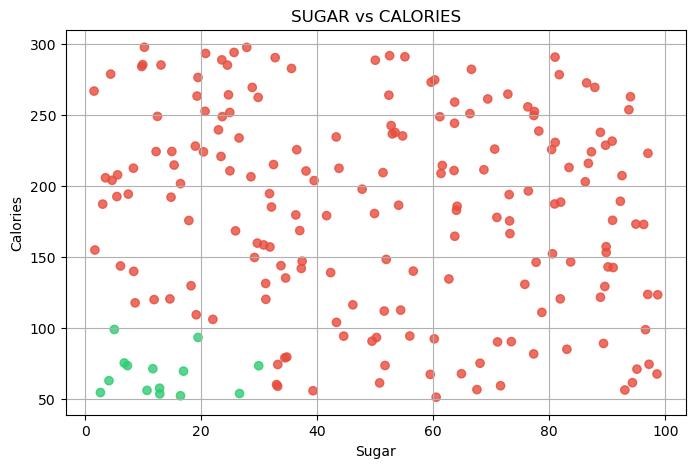

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
colors = df['level'].map({'Healthy': '#2ecc71', 'Junk': '#e74c3c'})
plt.scatter(df["Sugar"],df["Calories"],c=colors, alpha=0.8)
plt.title("SUGAR vs CALORIES")
plt.xlabel("Sugar")
plt.ylabel("Calories")
plt.grid(True)
plt.show()

# Sigmoid function

A sigmoid function is a bounded, differentiable mathematical function that maps any real number into an "S"-shaped curve with values between 0 and 1

z=b0+b1*x

sigma(x)=1/1+e^-x

The func which is most popular  --> Binary cross entropy

Binary cross entropy Error(E)=-(y*log(p) + (1-y)log(1-p))
 -y= actual class level
 -p=probability of class output(op of sigmoid function)
 
 
b0=1,b1=0.05
Input | actual class lvl (y) | predicted class level (p) | error(E)
1|0|1.34|-1
2|0|1.33|
5|1|1.28|
6|1|1.27|

accuracy=identifies sample/total sample

# Q1

In [5]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split,KFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

,Sugar,Calories,level
0,38.079472,210.507912,Junk
1,95.120716,71.034991,Junk
2,73.467400,90.407179,Junk
3,60.267190,274.638547,Junk
4,16.445845,201.607265,Junk
...,...,...,...
195,35.571748,282.689331,Junk
196,72.869612,264.603188,Junk
197,89.813916,157.248507,Junk
198,88.821556,237.717767,Junk


In [8]:
x_feature=df.drop(columns='level')
x_target=df['level']

#Apply train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x_feature, x_target, test_size=0.2, random_state=42)

# Creating Logistic Regression Model
model=LogisticRegression()
# Train the model
model.fit(x_train,y_train)

y_pred=model.predict(x_test)

class_output_compare=pd.DataFrame({'Actual class label':y_test,'Predicted class label':y_pred})
print(class_output_compare)

    Actual class label Predicted class label
95                Junk                  Junk
15                Junk                  Junk
30                Junk                  Junk
158               Junk                  Junk
128               Junk                  Junk
115               Junk                  Junk
69                Junk                  Junk
170               Junk                  Junk
174               Junk                  Junk
45                Junk                  Junk
66                Junk                  Junk
182               Junk                  Junk
165               Junk                  Junk
78                Junk                  Junk
186               Junk                  Junk
177               Junk                  Junk
56                Junk                  Junk
152               Junk                  Junk
82                Junk                  Junk
68                Junk                  Junk
124               Junk                  Junk
16        

In [11]:
correct_sample=np.sum(y_test.values == y_pred)

total=len(y_test)
accuracy=correct_sample/total
print("Correct Sample : ",correct_sample,"\nTotal : ",total)
accuracy

Correct Sample :  39 
Total :  40


0.975

# Q3

In [23]:
import numpy as np
import pandas as pd

data=pd.read_csv("breast_cancer_data.csv")
data

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,diagnosis
0,842302,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,M
1,842517,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,M
2,84300903,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,M
3,84348301,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,M
4,84358402,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,M
565,926682,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,M
566,926954,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,M
567,927241,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,M


In [24]:
data.describe()


,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [52]:
feature=data.drop(columns='diagnosis')
target=data['diagnosis']

x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=42)

# Creating Logistic Regression Model
model=LogisticRegression()
# Train the modelcorrect_sample=np.sum(y_test.values == y_pred)

total=len(y_test)
accuracy=correct_sample/total
print("Correct Sample : ",correct_sample,"\nTotal : ",total)
accuracy
model.fit(x_train,y_train)

y_pred=model.predict(x_test)
y_pred_train=model.predict(x_train)

class_output_compare=pd.DataFrame({'Actual label':y_test,'Predicted label':y_pred})
print(class_output_compare)

class_output_compare2=pd.DataFrame({'Actual label':y_train,'Predicted label':y_pred_train})
print(class_output_compare2)

    Actual label Predicted label
204            B               B
70             M               B
131            M               B
431            B               B
540            B               B
..           ...             ...
486            B               B
75             M               B
249            B               B
238            B               B
265            M               B

[114 rows x 2 columns]
    Actual label Predicted label
68             B               B
181            M               B
63             B               B
248            B               B
60             B               B
..           ...             ...
71             B               B
106            B               B
270            B               B
435            M               B
102            B               B

[455 rows x 2 columns]


In [53]:
correct_sample=np.sum(y_test.values == y_pred)

total=len(y_test)

accuracy=correct_sample/total
print("Correct Sample : ",correct_sample,"\nTotal : ",total)
accuracy

Correct Sample :  71 
Total :  114


0.6228070175438597

In [54]:
correct_sample=np.sum(y_train.values == y_pred_train)

total=len(y_train)

accuracy=correct_sample/total
print("Correct Sample : ",correct_sample,"\nTotal : ",total)
accuracy

Correct Sample :  286 
Total :  455


0.6285714285714286

In [73]:
from sklearn.model_selection import KFold, cross_val_score

# 3. Configure the N-Fold strategy (e.g., 5 folds)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run cross-validation
# This automatically handles the training and testing for each fold
scores = cross_val_score(model, feature, target, cv=kf, scoring='accuracy')

print("Accuracy per fold:", scores)
print("Mean Accuracy:", np.mean(scores))

Accuracy per fold: [0.62280702 0.6754386  0.37719298 0.62280702 0.59292035]
Mean Accuracy: 0.5782331936034778
